In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

from typing import Tuple, Dict, List, Optional, Union

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

import gaussoptfuncs

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251204_130856.log


In [2]:
from skimage.filters import gaussian, median

In [3]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
print(np.median(gain))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
print(np.median(offset))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
print(np.median(variance))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
print(np.median(readnoise))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

0.414377
32.3464
0.937415
2.33717


In [51]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 10
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), 1)
camera_parameters["offset"] = np.full((image_size, image_size), 0)
camera_parameters["variance"] = np.full((image_size, image_size), 1e-3)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-3)
camera_parameters["rqe"] = np.full((image_size, image_size), 1)
camera_parameters["pixel_QYs"] = np.vstack([B, G, R])
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
masks = M_F.get_masks(size_x=image_size, size_y=image_size)

camera_parameters["masks"] = masks
# camera_parameters["masks"] = masks

In [52]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter = "semrock-blp01-635r"
longpass_green_filter = "semrock-blp02-561r"
bandpass_green_filter = "semrock-ff01-582-64"
longpass_blue_filter = "semrock-blp01-488r"
bandpass_blue_filter = "semrock-ff01-520-44"
filters = [dichroic_mirror, notch_filter]
dyes = ["ATTO 594"]
_, dye_library = S_F.get_pixel_fractions_dye_and_filters(
    dyes,
    filters,
    wavelength,
    camera_parameters["pixel_QYs"],
)

In [53]:
ATTO488 = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 488'], wavelength=wavelength))
ATTO565 = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 565'], wavelength=wavelength))
ATTO594 = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 594'], wavelength=wavelength))
ATTO647N = np.squeeze(S_F.get_dye_or_filter_data(['ATTO 647N'], wavelength=wavelength))

In [54]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [55]:
pixel_size = 69
physical_image_size = pixel_size * np.array(camera_parameters["gain"].shape)

In [56]:
physical_image_size

array([690, 690])

In [57]:
x = np.array([0.5])
y = np.array([0.5])

In [58]:
positions = np.array([(x), (y)]).T * physical_image_size
X0, Y0 = np.meshgrid(positions[:, 0], positions[:, 1])
X0 = X0.ravel()
Y0 = Y0.ravel()

In [59]:
X0

array([ 345.])

In [60]:
x0y0 = {}
n_photons = {}
n_ph = 2000
for i, dye in enumerate(dyes):
    
    NA = 1.49
    s = 1
    n_photons[dye] = np.full(s, n_ph)
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[X0[i], Y0[i]]]).T


In [61]:
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dyes, filters, wavelength, camera_parameters["pixel_QYs"], normalized=False)
)

In [62]:
background_photons = int(20)
bayer_image_example, smoothed_image, _ = MSF.gen_camera_image_stack(
    camera_parameters,
    wavelength,
    average_emission_wavelengths,
    dye_pixel_efficiency,
    n_photons,
    x0y0,
    smoothing_function=smoothing_function,
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

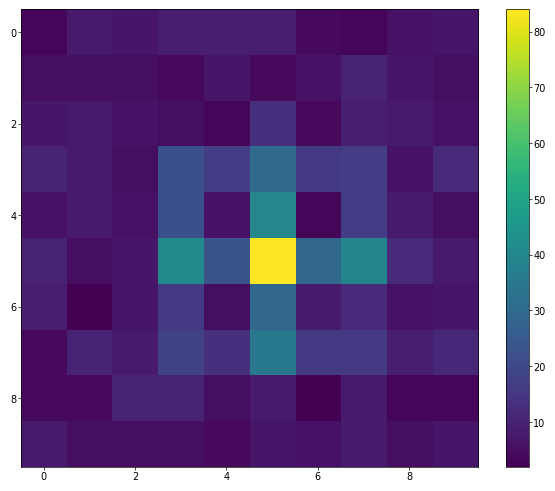

In [63]:
plt.imshow(bayer_image_example); plt.colorbar()

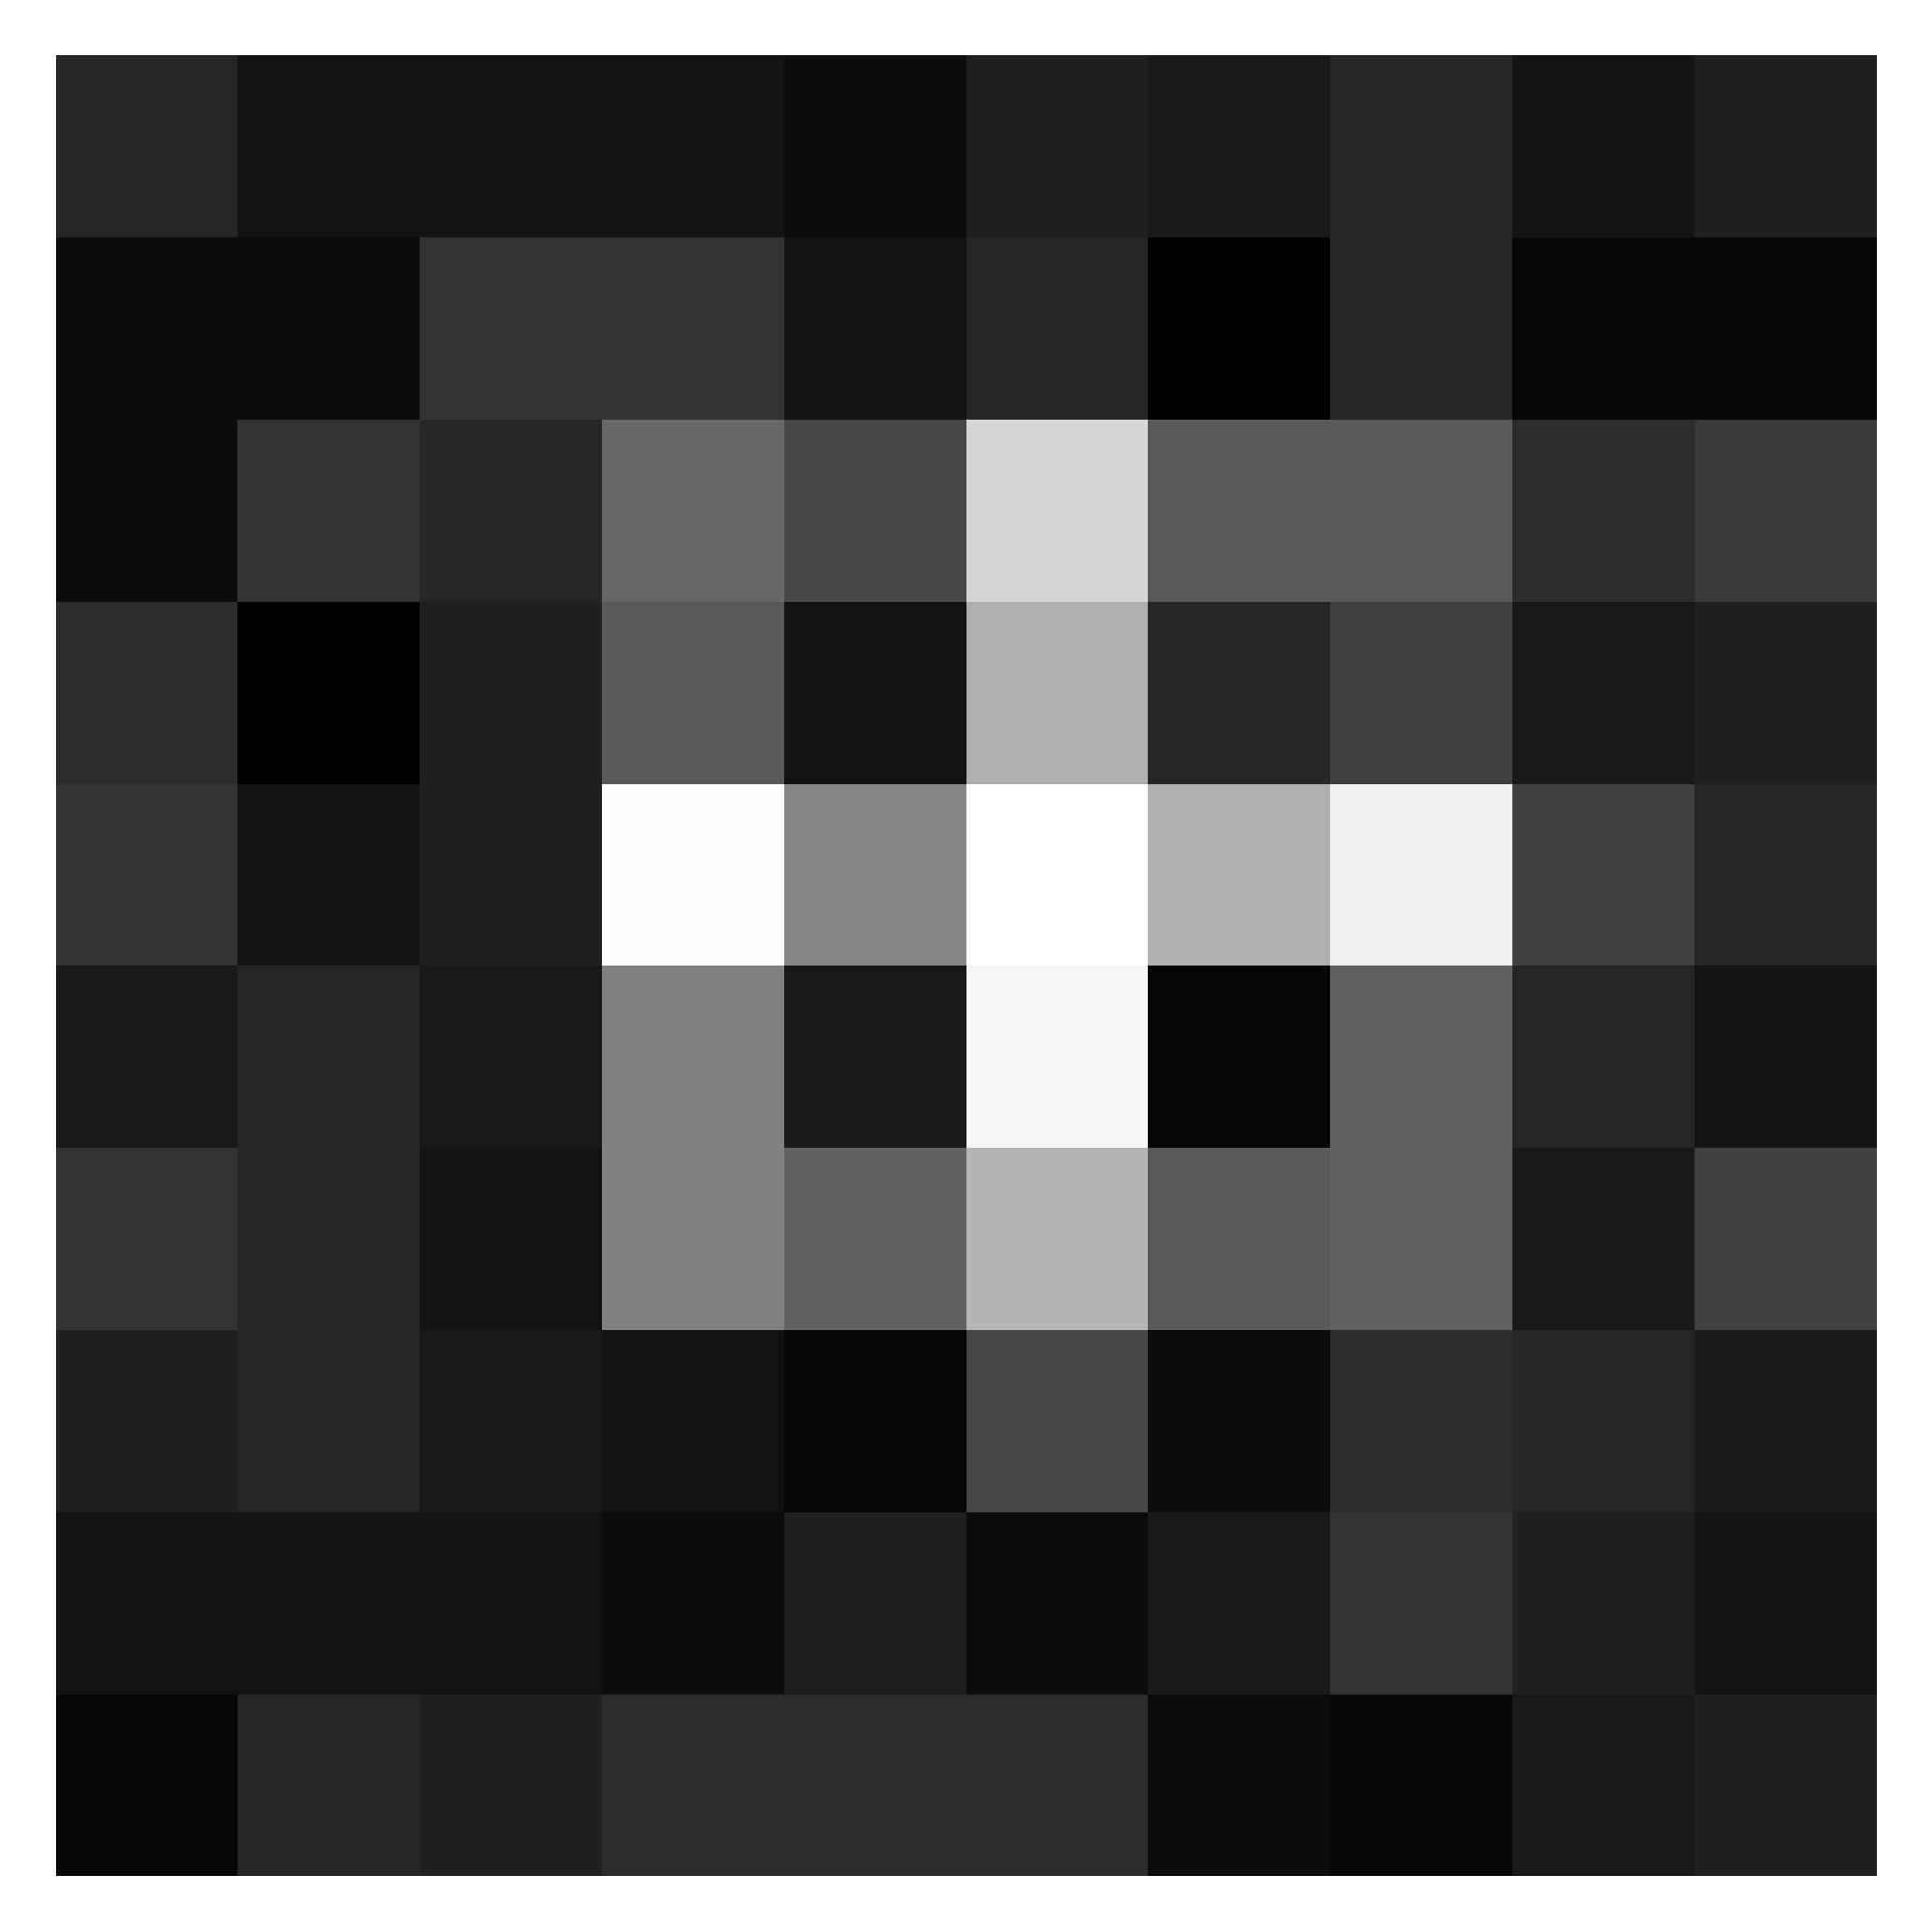

In [64]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image=bayer_image_example, pixelsize=69, colorbar=False, scalebarsize=300, scalebarlabel='300 nm')
plt.savefig('/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Grants/202508_EPSRC_Multicolour/Figures/Example_Simulation_ATTO594.svg', dpi=600, format='svg')
plt.show()

In [ ]:
all_x_positions = []
all_y_positions = []
all_colors = []

n=4
colors = plt.cm.nipy_spectral(np.linspace(0.35,0.98,n))


# Define colors for each dye
dye_color_map = {
    'ATTO 488': colors[0],
    'ATTO 565': colors[1],
    'ATTO 594': colors[2],
    'ATTO 647N': colors[3],
}

# Extract positions from first frame
for dye_name, positions in x0y0.items():
    frame_0 = positions[0]  # Shape: [2, n_molecules]
    x_coords = frame_0[0, :]  # All x coordinates in nm
    y_coords = frame_0[1, :]  # All y coordinates in nm

    all_x_positions.extend(x_coords)
    all_y_positions.extend(y_coords)

    # Assign color
    color = dye_color_map.get(dye_name, 'cyan')
    all_colors.extend([color] * len(x_coords))

all_x_positions = np.array(all_x_positions)
all_y_positions = np.array(all_y_positions)

print(f"Extracted {len(all_x_positions)} positions")


In [ ]:

fig, ax = plotter.create_subplots()

ax = plotter.overlay_localizations_with_contours(
    ax,
    image_data=bayer_image_example,
    positions_x=all_x_positions+(69/2),
    positions_y=all_y_positions+(69/2),
    colors=all_colors,
    pixelsize=pixel_size,
    marker_size=100,
    marker_linewidth=3,
    contour_sigma=50.0,  # PSF width in nm
    contour_levels=5,
    contour_alpha=1,
)

plt.title('Localization Overlay on Bayer Image')
plt.tight_layout()
plt.savefig('/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Grants/202508_EPSRC_Multicolour/Figures/Example_Simulation_Analysis.svg', dpi=600, format='svg')
plt.show()


In [ ]:
from render import render_gaussian

# Separate localizations by color
color_groups = {}
for i, color in enumerate(all_colors):
    if color not in color_groups:
        color_groups[color] = []
    color_groups[color].append(i)

# Define RGB values for each color
# Include both color names and hex codes
color_to_rgb = {
    'green': (0, 1, 0),
    'red': (1, 0, 0),
    'magenta': (1, 0, 1),
    'cyan': (0, 1, 1),
    '#32CD32': (0, 1, 0),      # Lime green (hex)
    '#FF00FF': (1, 0, 1),      # Magenta (hex)
    '#00FFFF': (0, 1, 1),      # Cyan (hex)
    '#FF0000': (1, 0, 0),      # Red (hex)
}

# Set rendering parameters
oversampling = 12  # High resolution
brightness_scale = 1.0  # Adjust if colors appear too bright/dim
sr_height = int(image_height * oversampling)
sr_width = int(image_width * oversampling)

# Create RGB image with black background
rgb_image = np.zeros((sr_height, sr_width, 3), dtype=np.float32)

# Render each color separately
for color_name, indices in color_groups.items():
    n_locs_color = len(indices)
    print(f"Rendering {n_locs_color} {color_name} spot(s)...")

    # Create recarray for this color
    dt = np.dtype([
        ('xc', 'f4'), ('yc', 'f4'),
        ('xc_err', 'f4'), ('yc_err', 'f4'),
        ('photons', 'f4'),
    ])

    locs_color = np.recarray(n_locs_color, dtype=dt)
    locs_color.xc = all_x_positions[indices] / pixel_size
    locs_color.yc = all_y_positions[indices] / pixel_size
    locs_color.xc_err = np.ones(n_locs_color) * 0.2  # Tight PSF
    locs_color.yc_err = np.ones(n_locs_color) * 0.2
    locs_color.photons = np.ones(n_locs_color) * 4000

    # Render grayscale for this color
    _, rendered = render_gaussian(
        locs=locs_color,
        oversampling=oversampling,
        y_min=0, x_min=0,
        y_max=image_height,
        x_max=image_width,
        min_blur_width=0.5,
    )

    print(f"  {color_name} render max: {rendered.max():.2f}")

    # Add to RGB channels WITHOUT normalization
    # Let all colors accumulate with their natural intensities
    rgb_values = color_to_rgb.get(color_name, (1, 1, 1))
    print(f"  {color_name} using RGB: {rgb_values}")

    for channel in range(3):
        rgb_image[:, :, channel] += rendered * rgb_values[channel]

print(f"\nBefore normalization - RGB max per channel: R={rgb_image[:,:,0].max():.2f}, G={rgb_image[:,:,1].max():.2f}, B={rgb_image[:,:,2].max():.2f}")

# Normalize ONCE at the end based on global maximum
# This preserves relative brightness between colors
global_max = rgb_image.max()
if global_max > 0:
    rgb_image = (rgb_image / global_max) * brightness_scale

# Clip to [0, 1] range
rgb_image = np.clip(rgb_image, 0, 1)

# Display
fig, ax = plotter.create_subplots()
ax.imshow(rgb_image, origin='lower')
ax.set_xticks([])
ax.set_yticks([])
plt.title(f'Multi-Color Super-Resolved ({oversampling}x)')
plt.tight_layout()
plt.savefig('/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Grants/202508_EPSRC_Multicolour/Figures/Example_Simulation_Render.svg', dpi=600, format='svg')
plt.show()



In [ ]:
def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5 * (x - mu) ** 2 / sigma**2)
    return y / np.max(y)

from copy import copy

R_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)
G_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)
B_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)

R_sharp = copy(R)
G_sharp = copy(G)
B_sharp = copy(B)
B_sharp[wavelength < 500] = np.max(G)
B_sharp[wavelength >= 500] = 0
G_sharp[(wavelength < 500) | (wavelength > 600)] = 0
G_sharp[(wavelength < 600) & (wavelength >= 500)] = np.max(G)
R_sharp[wavelength < 600] = 0
R_sharp[wavelength >= 600] = np.max(G)

wavelength = wavelength
pixel_QYs_normal = np.vstack([B, G, R])
pixel_QYs_broad = np.vstack([B_nonsharp, G_nonsharp, R_nonsharp])
pixel_QYs_sharp = np.vstack([B_sharp, G_sharp, R_sharp])

In [ ]:
fig, axs = plotter.create_subplots(nrows=2)

axs[0] = plotter.line_plot(ax=axs[0], x=wavelength, y=R, color='#ff2a2a')
axs[0] = plotter.line_plot(ax=axs[0], x=wavelength, y=G, color='#49b500')
axs[0] = plotter.line_plot(ax=axs[0], x=wavelength, y=B, ylabel='camera QE', xlabel='wavelength/nm', color='#5555ff')

axs[0].set_xlim([400, 900])
axs[0].set_ylim([0, 0.7])

axs[1] = plotter.line_plot(ax=axs[1], x=wavelength, y=R_sharp, color='#ff0000')
axs[1] = plotter.line_plot(ax=axs[1], x=wavelength, y=G_sharp, color='#32cd32')
axs[1] = plotter.line_plot(ax=axs[1], x=wavelength, y=B_sharp, ylabel='camera QE', xlabel='wavelength/nm', color='#0000ff')

axs[1].set_xlim([400, 900])
axs[1].set_ylim([0, 0.7])

plt.savefig('/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Grants/202508_EPSRC_Multicolour/Figures/Camera_types.svg', dpi=600, format='svg')
plt.show()

In [ ]:
def generate_ring_positions(
    N: int,
    image_size: int,
    pixel_size: float,
    ring_radius_fraction: float = 0.3,
    center_offset: Tuple[float, float] = (0.0, 0.0),
    add_noise: bool = False,
    noise_sigma: float = 10.0,
    start_angle: float = 0.0
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate N molecular positions arranged in a ring pattern.

    Args:
        N (int): Number of molecules to place in the ring
        image_size (int): Size of the image in pixels (assumes square image)
        pixel_size (float): Physical size of each pixel (e.g., 69 nm)
        ring_radius_fraction (float): Fraction of image radius for the ring (0.0-0.5)
        center_offset (Tuple[float, float]): Offset from image center in nm (x, y)
        add_noise (bool): Whether to add Gaussian noise to positions
        noise_sigma (float): Standard deviation of position noise in nm
        start_angle (float): Starting angle in radians (0 = positive x-axis)

    Returns:
        Tuple[np.ndarray, np.ndarray]: X and Y coordinates in nm

    Examples:
        # Simple ring of 8 molecules
        x_coords, y_coords = generate_ring_positions(8, 16, 69)

        # Larger ring with noise
        x_coords, y_coords = generate_ring_positions(12, 32, 69,
                                                   ring_radius_fraction=0.4,
                                                   add_noise=True,
                                                   noise_sigma=20.0)
    """
    # Calculate physical image dimensions
    physical_size = image_size * pixel_size
    center_x = physical_size / 2 + center_offset[0]
    center_y = physical_size / 2 + center_offset[1]

    # Calculate ring radius
    max_radius = physical_size / 2
    ring_radius = max_radius * ring_radius_fraction

    # Generate angles for N evenly spaced points
    angles = np.linspace(start_angle, start_angle + 2 * np.pi, N, endpoint=False)

    # Calculate positions
    x_coords = center_x + ring_radius * np.cos(angles)
    y_coords = center_y + ring_radius * np.sin(angles)

    # Add noise if requested
    if add_noise:
        x_noise = np.random.normal(0, noise_sigma, N)
        y_noise = np.random.normal(0, noise_sigma, N)
        x_coords += x_noise
        y_coords += y_noise

    # Ensure coordinates are within bounds
    x_coords = np.clip(x_coords, 0, physical_size)
    y_coords = np.clip(y_coords, 0, physical_size)

    return x_coords, y_coords

def positions_to_x0y0_format(
    x_coords: np.ndarray,
    y_coords: np.ndarray,
    dye_names: List[str],
    frames: int = 1,
    mode: str = "all",
    random_seed: Optional[int] = None,
    localization_noise_sigma: float = 0.0,
    image_size: Optional[int] = None,
    pixel_size: Optional[float] = None
) -> Dict[str, np.ndarray]:
    """
    Convert position arrays to the x0y0 format expected by simulation functions.

    Args:
        x_coords (np.ndarray): X coordinates in nm
        y_coords (np.ndarray): Y coordinates in nm
        dye_names (List[str]): List of dye names to assign molecules to
        frames (int): Number of frames
        mode (str): Activation mode:
            - "all": All molecules active in all frames (default)
            - "SMLM": Only one randomly selected molecule active per frame
            - "sequential": Molecules activate in order (cycling through)
        random_seed (Optional[int]): Random seed for reproducible SMLM simulation
        localization_noise_sigma (float): Standard deviation of Gaussian noise to add
            to molecular positions in nm (simulates localization uncertainty)
        image_size (Optional[int]): Image size in pixels (for bounds checking when adding noise)
        pixel_size (Optional[float]): Pixel size in nm (for bounds checking when adding noise)

    Returns:
        Dict[str, np.ndarray]: Dictionary in x0y0 format for simulation functions

    Examples:
        # All molecules active every frame
        x0y0 = positions_to_x0y0_format(x_coords, y_coords, ["ATTO 565"])

        # SMLM mode: one random molecule per frame
        x0y0 = positions_to_x0y0_format(x_coords, y_coords, ["ATTO 565"],
                                       frames=100, mode="SMLM")

        # SMLM with localization noise (realistic experiment)
        x0y0 = positions_to_x0y0_format(x_coords, y_coords, ["ATTO 565"],
                                       frames=100, mode="SMLM",
                                       localization_noise_sigma=15.0,
                                       image_size=32, pixel_size=69)

        # Sequential activation with noise
        x0y0 = positions_to_x0y0_format(x_coords, y_coords, ["ATTO 565"],
                                       frames=50, mode="sequential",
                                       localization_noise_sigma=10.0)
    """
    n_molecules = len(x_coords)
    n_dyes = len(dye_names)

    # Set random seed for reproducibility
    if random_seed is not None:
        np.random.seed(random_seed)

    # Distribute molecules among dyes
    molecules_per_dye = n_molecules // n_dyes
    remainder = n_molecules % n_dyes

    x0y0 = {}
    start_idx = 0

    for i, dye in enumerate(dye_names):
        # Calculate how many molecules this dye gets
        n_this_dye = molecules_per_dye + (1 if i < remainder else 0)
        end_idx = start_idx + n_this_dye

        # Extract coordinates for this dye
        dye_x = x_coords[start_idx:end_idx]
        dye_y = y_coords[start_idx:end_idx]

        if mode == "all":
            # All molecules active in all frames (original behavior)
            x0y0[dye] = np.zeros([frames, 2, n_this_dye])
            for frame in range(frames):
                x0y0[dye][frame, 0, :] = dye_x  # X coordinates
                x0y0[dye][frame, 1, :] = dye_y  # Y coordinates

        elif mode == "SMLM":
            # Only one randomly selected molecule active per frame
            # Format: [frames, 2, 1] - always 1 molecule per frame, correct dimension order
            x0y0[dye] = np.zeros([frames, 2, 1])

            for frame in range(frames):
                # Randomly select one molecule for this frame
                selected_idx = np.random.randint(0, n_this_dye)
                base_x = dye_x[selected_idx]
                base_y = dye_y[selected_idx]

                # Add Gaussian localization noise
                if localization_noise_sigma > 0:
                    noise_x = np.random.normal(0, localization_noise_sigma)
                    noise_y = np.random.normal(0, localization_noise_sigma)
                    noisy_x = base_x + noise_x
                    noisy_y = base_y + noise_y

                    # Apply bounds checking if image dimensions provided
                    if image_size is not None and pixel_size is not None:
                        max_coord = image_size * pixel_size
                        noisy_x = np.clip(noisy_x, 0, max_coord)
                        noisy_y = np.clip(noisy_y, 0, max_coord)

                    x0y0[dye][frame, 0, 0] = noisy_x  # X coordinate with noise
                    x0y0[dye][frame, 1, 0] = noisy_y  # Y coordinate with noise
                else:
                    x0y0[dye][frame, 0, 0] = base_x  # X coordinate
                    x0y0[dye][frame, 1, 0] = base_y  # Y coordinate

        elif mode == "sequential":
            # Molecules activate in sequential order (cycling through)
            # Format: [frames, 2, 1] - always 1 molecule per frame, correct dimension order
            x0y0[dye] = np.zeros([frames, 2, 1])

            for frame in range(frames):
                # Select molecule based on frame number (cycling through)
                selected_idx = frame % n_this_dye
                base_x = dye_x[selected_idx]
                base_y = dye_y[selected_idx]

                # Add Gaussian localization noise
                if localization_noise_sigma > 0:
                    noise_x = np.random.normal(0, localization_noise_sigma)
                    noise_y = np.random.normal(0, localization_noise_sigma)
                    noisy_x = base_x + noise_x
                    noisy_y = base_y + noise_y

                    # Apply bounds checking if image dimensions provided
                    if image_size is not None and pixel_size is not None:
                        max_coord = image_size * pixel_size
                        noisy_x = np.clip(noisy_x, 0, max_coord)
                        noisy_y = np.clip(noisy_y, 0, max_coord)

                    x0y0[dye][frame, 0, 0] = noisy_x  # X coordinate with noise
                    x0y0[dye][frame, 1, 0] = noisy_y  # Y coordinate with noise
                else:
                    x0y0[dye][frame, 0, 0] = base_x  # X coordinate
                    x0y0[dye][frame, 1, 0] = base_y  # Y coordinate

        else:
            raise ValueError(f"Unknown mode '{mode}'. Options: 'all', 'SMLM', 'sequential'")

        start_idx = end_idx

    return x0y0



In [ ]:
x_coords, y_coords = generate_ring_positions(2, 10, pixel_size, ring_radius_fraction=0.01, center_offset=(0, 0))

x0y0 = positions_to_x0y0_format(x_coords, y_coords, dyes, frames=4000, mode='SMLM', localization_noise_sigma = 10)
n_photons = {}
for key in x0y0:
    n_photons[key] = np.full(len(x0y0[key]), n_ph)

In [ ]:
x0y0['ATTO 647N'].shape

In [ ]:
background_photons = int(30)
bayer_image_example, smoothed_image, _ = MSF.gen_camera_image_stack(
    camera_parameters,
    wavelength,
    average_emission_wavelengths,
    dye_pixel_efficiency,
    n_photons,
    x0y0,
    smoothing_function=smoothing_function,
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

In [ ]:
posdata = x0y0['ATTO 647N']

In [ ]:
xdata = posdata[:, 0]
ydata = posdata[:, 1]

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs, x=xdata, y=ydata, xaxislabel='x / nm', yaxislabel='y / nm', lw=0.5)

plt.savefig("Scatter_Ring.svg")


In [ ]:
for i in np.arange(bayer_image_example.shape[0])[::100]:
    fig, axs = plotter.one_column_plot(width=2, height=2)
    
    data = bayer_image_example[i, :, :]
    locdata = x0y0['ATTO 647N'][i]/69
    xdata = locdata[0]
    ydata = locdata[1]
    axs = plotter.image_scatter_plot(
        axs, data, xdata=xdata, ydata=ydata, scalebarlabel="300 nm", scalebarsize=300, vmax=np.percentile(data, 99),
        cbar='off', marker='x', s=20, facecolor='red', pixelsize=69,
    )
    
    plt.savefig("Ring_frame_"+str(i)+"_ATTO647N.svg")

In [ ]:
fig, axs = plotter.one_column_plot()

data = bayer_image_example
axs = plotter.image_plot(
    axs, data, scalebarlabel="300 nm", scalebarsize=300, vmax=np.percentile(data, 99)
)

plt.savefig("Ring_onemoleculeon.svg")

In [ ]:
from src import render

In [ ]:
def x0y0_to_localization_table(
    x0y0: Dict[str, np.ndarray],
    n_photons: Dict[str, Union[int, np.ndarray]],
    pixel_size: float = 69.0,
    default_sigma: float = 1.5,
    default_background: float = 10.0,
    localization_precision_nm: float = 10.0,
    amp_scale_factor: float = 1000.0
) -> np.ndarray:
    """
    Convert x0y0 simulation format to localization table format for render.py.

    This function converts molecular positions from the simulation format (x0y0)
    to a structured numpy array (recarray) that can be used with render.py
    for super-resolution image rendering.

    Args:
        x0y0 (Dict[str, np.ndarray]): Dictionary of molecular positions per dye
            Format: {dye_name: array([frames, 2, molecules])}
        n_photons (Dict[str, Union[int, np.ndarray]]): Photon counts per dye
        pixel_size (float): Pixel size in nm (default: 69.0)
        default_sigma (float): Default PSF sigma in pixels (default: 1.5)
        default_background (float): Default background level (default: 10.0)
        localization_precision_nm (float): Localization precision in nm (default: 15.0)
        amp_scale_factor (float): Scaling factor for amplitude values (default: 1000.0)

    Returns:
        np.ndarray: Structured array (recarray) with fields expected by render.py:
            - xc, yc: Position coordinates in nm
            - frame: Frame number (0-indexed)
            - s_x, s_y: PSF width in nm
            - xc_err, yc_err: Localization precision in nm

    Examples:
        # Convert SMLM simulation to localization table
        locs = x0y0_to_localization_table(x0y0, n_photons, pixel_size=69)

        # Use with render.py
        from src import render
        image, _, _, _, _, _ = render.render_hist(locs, oversampling=10)

        # Custom parameters
        locs = x0y0_to_localization_table(
            x0y0, n_photons,
            pixel_size=69,
            localization_precision_nm=12.0,  # High precision
            amp_scale_factor=2000.0          # Brighter rendering
        )
    """
    # Count total localizations across all dyes and frames
    total_locs = 0
    dye_info = {}

    for dye_name, positions in x0y0.items():
        frames, coords, molecules = positions.shape
        # Count non-zero positions (active molecules)
        active_positions = 0
        for frame in range(frames):
            for mol in range(molecules):
                # Check if molecule is active (non-zero position)
                if positions[frame, 0, mol] != 0 or positions[frame, 1, mol] != 0:
                    active_positions += 1

        dye_info[dye_name] = {
            'positions': positions,
            'active_count': active_positions,
            'photons': n_photons.get(dye_name, 1000)
        }
        total_locs += active_positions

    # Define the data type for localization table (compatible with render.py)
    loc_dtype = np.dtype([
        ('xc', 'f4'),      # X coordinate (nm)
        ('yc', 'f4'),      # Y coordinate (nm)
        ('frame', 'i4'),   # Frame number
        ('s_x', 'f4'),     # PSF sigma X (nm)
        ('s_y', 'f4'),     # PSF sigma Y (nm)
        ('xc_err', 'f4'),  # X localization error (nm)
        ('yc_err', 'f4'),  # Y localization error (nm)
    ])

    # Create structured array
    locs = np.zeros(total_locs, dtype=loc_dtype)

    # Convert PSF sigma from pixels to nm
    sigma_nm = default_sigma * pixel_size

    # Fill the localization table
    loc_idx = 0

    for dye_idx, (dye_name, info) in enumerate(dye_info.items()):
        positions = info['positions']
        photon_count = info['photons']
        frames, coords, molecules = positions.shape

        # Calculate amplitude based on photon count
        amplitude = photon_count * amp_scale_factor / 1000.0  # Normalize to reasonable range

        for frame in range(frames):
            for mol in range(molecules):
                x_pos = positions[frame, 0, mol]/pixel_size
                y_pos = positions[frame, 1, mol]/pixel_size

                # Skip inactive molecules (position = 0,0 typically means inactive)
                if x_pos == 0 and y_pos == 0:
                    continue

                # Fill localization data
                locs[loc_idx]['xc'] = x_pos
                locs[loc_idx]['yc'] = y_pos
                locs[loc_idx]['frame'] = frame

                # Set PSF parameters
                locs[loc_idx]['s_x'] = sigma_nm/pixel_size
                locs[loc_idx]['s_y'] = sigma_nm/pixel_size

                # Set localization precision
                locs[loc_idx]['xc_err'] = localization_precision_nm/pixel_size
                locs[loc_idx]['yc_err'] = localization_precision_nm/pixel_size

                loc_idx += 1

    # Convert to recarray for compatibility with render.py
    return locs.view(np.recarray)


In [ ]:
loc_data = x0y0_to_localization_table(x0y0, n_photons)

In [ ]:
loc_data

In [ ]:
image = render.render(
    locs=loc_data,
    oversampling=8,
    viewport=((0, 0), (16, 16)),
    blur_method="gaussian",
)[1]

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image, vmin=np.percentile(image, 0), vmax=np.percentile(image, 100), cmap='hot', pixelsize=69/8,
                        scalebarsize=300, scalebarlabel='300 nm')

axs.set_xlim([40, 85])
axs.set_ylim([40, 85])
plt.savefig('Example_SRrender.svg')
plt.show()

In [ ]:
camera_calibration = camera_parameters

In [ ]:
folder = "/home/jbeckwith/Documents/pCloud/Job Applications/URF/2025/ResearchProposal/Figures/Multicolour/"

fig, axs = plotter.two_column_plot(ncolumns=4, widthratio=[1, 1, 1, 1])

axs[0] = plotter.image_plot(
    axs[0],
    data=normal_image,
    scalebarlabel="200 nm",
    scalebarsize=200,
    vmin=np.percentile(normal_image, 0.01),
    vmax=np.percentile(normal_image, 99),
    cbar="off",
)
axs[1] = plotter.image_plot(
    axs[1],
    data=bayer_image_example,
    scalebarlabel="200 nm",
    scalebarsize=200,
    vmin=np.percentile(bayer_image_example, 0.01),
    vmax=np.percentile(bayer_image_example, 99),
    cbar="off",
)

axs[2] = plotter.image_plot(
    axs[2],
    data=normal_image,
    scalebarlabel="200 nm",
    scalebarsize=200,
    vmin=np.percentile(normal_image, 0.01),
    vmax=np.percentile(normal_image, 99),
    cbar="off",
)
axs[3] = plotter.image_plot(
    axs[3],
    data=bayer_image_example,
    scalebarlabel="200 nm",
    scalebarsize=200,
    vmin=np.percentile(bayer_image_example, 0.01),
    vmax=np.percentile(bayer_image_example, 99),
    cbar="off",
)

plt.savefig(os.path.join(folder, "example_bayer_concept.svg"), dpi=600, format="svg")
plt.show()

In [ ]:
plt.imshow(bayer_image_example)
plt.colorbar()

In [ ]:
photoelectron_data = np.divide(
    np.divide(
        np.subtract(bayer_image, camera_parameters["offset"]),
        camera_parameters["gain"],
    ),
    camera_parameters["rqe"],
)

In [ ]:
smoothed_data = np.divide(
    np.divide(
        np.subtract(smoothed_image, camera_parameters["offset"]),
        camera_parameters["gain"],
    ),
    camera_parameters["rqe"],
)

In [ ]:
masks_3d = np.dstack([masks["B"], masks["G"], masks["R"]])

In [ ]:
gaussoptfuncs.initial_guess(smoothed_data, photoelectron_data, masks_3d)

In [ ]:
%timeit gaussoptfuncs.initial_guess(smoothed_data, photoelectron_data, masks_3d)

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

axs[0] = plotter.image_plot(
    axs=axs[0], data=bayer_image_Cy5[0, :, :], scalebarsize=200, scalebarlabel="200 nm"
)
axs[1] = plotter.image_plot(
    axs=axs[1],
    data=bayer_image_fakecamera[0, :, :],
    scalebarsize=200,
    scalebarlabel="200 nm",
)

In [ ]:
n_photons = {}
s = 10000
n_photons["Alexa Fluor 647"] = np.full(s, 2000)
# n_photons["CF680"] = np.full(s, 5000)

dyes = np.zeros([2, len(wavelength)])

x0y0 = {}
max = pixel_size * image_size

dyes = list(n_photons.keys())
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dyes, filters, wavelength, pixel_QYs)
)

center = max / 2
scaling = 1000

image_size = pixel_size * np.array(camera_parameters["gain"].shape)
x0 = np.full(s, (image_size[0]) / 2) + np.random.normal(scale=2 * pixel_size, size=s)
y0 = np.full(s, (image_size[1]) / 2) + np.random.normal(scale=2 * pixel_size, size=s)

for dye in n_photons:
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[x0, y0]]).T

bayer_image_AF647, normal_image = MSF.gen_camera_image_stack(
    camera_parameters,
    wavelength,
    average_emission_wavelengths,
    dye_pixel_efficiency,
    n_photons,
    x0y0,
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=True,
)

In [ ]:
photoelectron_data_Cy5 = np.divide(
    np.divide(
        np.subtract(bayer_image_Cy5, camera_parameters["offset"]),
        camera_parameters["gain"],
    ),
    camera_parameters["rqe"],
)

photoelectron_data_AF647 = np.divide(
    np.divide(
        np.subtract(bayer_image_AF647, camera_parameters["offset"]),
        camera_parameters["gain"],
    ),
    camera_parameters["rqe"],
)

In [ ]:
smoothing_value = np.arange(2, 16)
error_values = np.zeros(len(smoothing_value))
for j, s_v in enumerate(smoothing_value):
    print(
        "Analysing smoothing value {} \n".format(s_v),
        end="\r",
        flush=True,
    )
    erd_Cy5 = sCMOS.var_weighted_uniform_filter(
        photoelectron_data_Cy5, camera_parameters["variance"], s_v
    )
    erd_Cy5[erd_Cy5 < 0] = 0
    erd_Cy5 = erd_Cy5 + 1
    error_map_Cy5 = np.add(erd_Cy5, np.square(camera_parameters["readnoise"]))
    weights_map_Cy5 = np.power(error_map_Cy5, -2)

    erd_AF647 = sCMOS.var_weighted_uniform_filter(
        photoelectron_data_AF647, camera_parameters["variance"], s_v
    )
    erd_AF647[erd_AF647 < 0] = 0
    erd_AF647 = erd_AF647 + 1
    error_map_AF647 = np.add(erd_AF647, np.square(camera_parameters["readnoise"]))
    weights_map_AF647 = np.power(error_map_AF647, -2)

    masks_3d = np.dstack(
        [camera_parameters["masks"][x] for x in camera_parameters["masks"].keys()]
    )
    vals = np.zeros([1000, 2])
    for i in np.arange(1000):
        pd_fit_Cy5 = photoelectron_data_Cy5[i, :, :]
        wm_fit_Cy5 = weights_map_Cy5[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(erd_Cy5[i, :, :] - 1)
        initial_guess = np.concatenate(
            [np.array([x_ig, y_ig, A, 1.5, b]), np.mean(dye_library, axis=0)]
        )
        args = {
            "data": pd_fit_Cy5,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_Cy5,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb": b * 2,
        }
        import types

        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour_MIN
        result = fitter.fit_function(**args)
        vals[i, 0] = np.abs(
            np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1))
            - 0
        )

        pd_fit_AF647 = photoelectron_data_AF647[i, :, :]
        wm_fit_AF647 = weights_map_AF647[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(erd_AF647[i, :, :] - 1)
        initial_guess = np.concatenate(
            [np.array([x_ig, y_ig, A, 1.5, b]), np.mean(dye_library, axis=0)]
        )
        args = {
            "data": pd_fit_AF647,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_AF647,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb": b * 2,
        }
        import types

        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour_MIN
        result = fitter.fit_function(**args)
        vals[i, 1] = np.abs(
            np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1))
            - 1
        )

    print(
        "Smoothing mean {}, smoothing std {} \n".format(
            np.nanmean(vals), np.nanstd(vals)
        ),
        end="\r",
    )
    error_values[j] = np.nanmean(vals)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(
    axs=axs,
    x=smoothing_value,
    y=error_values * 100,
    xaxislabel="Smoothing radius",
    yaxislabel="% error",
)

folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250327/fig/multicolour_camera/smoothing/"
file = "MIN_smoothingparam.svg"
plt.savefig(os.path.join(folder, file), dpi=600, format="svg")

In [ ]:
smoothing_value = np.arange(2, 16)
error_values = np.zeros(len(smoothing_value))
for j, s_v in enumerate(smoothing_value):
    print(
        "Analysing smoothing value {} \n".format(s_v),
        end="\r",
        flush=True,
    )
    erd_Cy5 = sCMOS.var_weighted_uniform_filter(
        photoelectron_data_Cy5, camera_parameters["variance"], s_v
    )
    erd_Cy5[erd_Cy5 < 0] = 0
    erd_Cy5 = erd_Cy5 + 1
    error_map_Cy5 = np.add(erd_Cy5, np.square(camera_parameters["readnoise"]))
    weights_map_Cy5 = np.power(error_map_Cy5, -2)

    erd_AF647 = sCMOS.var_weighted_uniform_filter(
        photoelectron_data_AF647, camera_parameters["variance"], s_v
    )
    erd_AF647[erd_AF647 < 0] = 0
    erd_AF647 = erd_AF647 + 1
    error_map_AF647 = np.add(erd_AF647, np.square(camera_parameters["readnoise"]))
    weights_map_AF647 = np.power(error_map_AF647, -2)

    masks_3d = np.dstack(
        [camera_parameters["masks"][x] for x in camera_parameters["masks"].keys()]
    )
    vals = np.zeros([1000, 2])
    for i in np.arange(1000):
        pd_fit_Cy5 = photoelectron_data_Cy5[i, :, :]
        wm_fit_Cy5 = weights_map_Cy5[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(erd_Cy5[i, :, :] - 1)
        initial_guess = np.concatenate(
            [np.array([x_ig, y_ig, A, 1.5, b]), np.mean(dye_library, axis=0)]
        )
        args = {
            "data": pd_fit_Cy5,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_Cy5,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb": b * 2,
        }
        import types

        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour
        result = fitter.fit_function(**args)
        vals[i, 0] = np.abs(
            np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1))
            - 0
        )

        pd_fit_AF647 = photoelectron_data_AF647[i, :, :]
        wm_fit_AF647 = weights_map_AF647[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(erd_AF647[i, :, :] - 1)
        initial_guess = np.concatenate(
            [np.array([x_ig, y_ig, A, 1.5, b]), np.mean(dye_library, axis=0)]
        )
        args = {
            "data": pd_fit_AF647,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_AF647,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb": b * 2,
        }
        import types

        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour
        result = fitter.fit_function(**args)
        vals[i, 1] = np.abs(
            np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1))
            - 1
        )

    print(
        "Smoothing mean {}, smoothing std {} \n".format(
            np.nanmean(vals), np.nanstd(vals)
        ),
        end="\r",
    )
    error_values[j] = np.nanmean(vals)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(
    axs=axs,
    x=smoothing_value,
    y=error_values * 100,
    xaxislabel="Smoothing radius",
    yaxislabel="% error",
)

folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250327/fig/multicolour_camera/smoothing/"
file = "LM_smoothingparam.svg"
plt.savefig(os.path.join(folder, file), dpi=600, format="svg")

In [ ]:
dye_n = np.argmin(np.sum(np.abs(dye_fit_expectation - dye_library), axis=1))
dye_n

In [ ]:
def plot_image_fft(input_image, n_labels=7, d=1):
    """
    Plot an image alongside its frequency-domain representation.


    Parameters
    ----------
    img_path: (str) the path to an image
    n_labels: (int) the number of labels to space out along each axis, default=7
                      best if an odd number

    d: (int) sample spacing (inverse of the sampling rate). default=1
                      if the image has meaningful units, this can be altered to match

    """

    # trying to get the units of the FFT plot
    #  "The returned float array `f` contains the frequency bin centers in cycles
    #   per unit of the sample spacing (with zero at the start).  For instance, if
    #  the sample spacing is in seconds, then the frequency unit is cycles/second."
    freqx = np.fft.fftfreq(input_image.shape[1], d=1)
    freqy = np.fft.fftfreq(input_image.shape[0], d=1)
    x_step = int(input_image.shape[1] / n_labels)
    xtick_pos = np.arange(0, input_image.shape[1])[::x_step]
    xtick_labels = np.round(freqx[::x_step], 2)
    y_step = int(input_image.shape[0] / n_labels)
    ytick_pos = np.arange(0, input_image.shape[0])[::y_step]
    ytick_labels = np.round(freqy[::y_step], 2)

    # convert to frequency domain
    img_freq = np.fft.fft2(input_image)

    # calculate amplitude spectrum
    img_amp = np.fft.fftshift(np.abs(img_freq))

    # for display, take the logarithm
    img_amp_disp = np.log10(img_amp)

    # rescale to [0.0, 1.0] for display

    fig, ax = plt.subplots(1, 2, figsize=(10, 6))
    ax[0].imshow(input_image)
    ax[1].imshow(img_amp_disp)
    ax[1].set_xticks(xtick_pos, xtick_labels)
    ax[1].set_yticks(ytick_pos, ytick_labels)
    plt.show()
    plt.close()

In [ ]:
photon_levels = np.array([500, 1000, 2000])
background_level = 10
n_molecules = 100

In [ ]:
data = np.zeros([len(photon_levels), n_molecules])
for i, photon in enumerate(photon_levels):
    data[i, :] = np.random.poisson(lam=photon + background_level, size=n_molecules)

In [ ]:
data[0, :]

In [ ]:
fig, axs = plotter.one_column_plot(height=1.5)

axs = plotter.histogram_plot(
    axs=axs,
    data=data[0, :],
    bins=np.histogram_bin_edges(data[0, :], bins="sturges"),
    alpha=1,
    xaxislabel="estimated photons per molecule",
    density=False,
)
# axs = plotter.histogram_plot(axs=axs, data=data[1, :], bins=np.histogram_bin_edges(data[1, :], bins='sturges'), alpha=1, xaxislabel='estimated photons per molecule', density=False)
# axs = plotter.histogram_plot(axs=axs, data=data[2, :], bins=np.histogram_bin_edges(data[2, :], bins='sturges'), alpha=1, xaxislabel='estimated photons per molecule', density=False)

save_folder = (
    r"C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee"
)
# save_folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/dye_unmixing'

axs.set_xlim([400, 700])
save_file = "example_500photons_hist.svg"
plt.savefig(os.path.join(save_folder, save_file), dpi=600, format="svg")

In [ ]:
plt.imshow(bayer_image)
plt.colorbar()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=bayer_image,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
    cbarlabel="intensity",
)

save_folder = (
    r"C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee"
)
# save_folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/dye_unmixing'

save_file = "example_500photons.svg"
plt.savefig(os.path.join(save_folder, save_file), dpi=600, format="svg")

In [ ]:
from SpotDetectionFunctions import SpotDetection_Functions

SD_F = SpotDetection_Functions()

In [ ]:
puncta = SD_F.detect_puncta_in_image(bayer_image, mf_factor=3, local_factor=3)

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1, 1, 1])

axs[0] = plotter.image_plot(
    axs=axs[0],
    data=bayer_image,
    scalebarsize=300,
    scalebarlabel="300 nm",
    cbarlabel="image intensity",
)
axs[1] = plotter.image_plot(
    axs=axs[1],
    data=filtered_image,
    scalebarsize=300,
    scalebarlabel="300 nm",
    cbar="off",
)
axs[2] = plotter.image_scatter_plot(
    axs=axs[2],
    data=bayer_image,
    xdata=puncta[:, 0],
    ydata=puncta[:, 1],
    s=1000,
    lws=1,
    scalebarsize=300,
    scalebarlabel="300 nm",
    cbar="off",
)

save_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/spot_detection/"
save_file = "example_spotdetection_multicolour.svg"
plt.savefig(os.path.join(save_folder, save_file), dpi=600, format="svg")

In [ ]:
image_for_detection = image_for_detection = np.divide(bayer_image, 1)
psf_fun = SD_F.gauss2d
sigma = np.divide(PSF.sigma_PSF(0.6, 1.49), 0.069)
mf_factor = 3
mf_range = int(np.ceil(mf_factor * sigma))
w = SD_F.get_mf(psf_fun, sigma, mf_range)
guard_interval = int(np.ceil(mf_factor * sigma))
reference_interval = int(np.ceil(mf_factor * sigma))
local_max_range = int(np.ceil(3 * sigma))
filtered_image = SD_F.filter_image(image_for_detection, w)
square_annulus = SD_F.get_square_annulus(guard_interval, reference_interval)

In [ ]:
plt.imshow(filtered_image)
plt.colorbar()

In [ ]:
b_estimate = SD_F.cacfar_background_mean_estimate(filtered_image, square_annulus)
b_std_estimate = SD_F.cacfar_background_std_estimate(
    filtered_image, b_estimate, square_annulus
)

In [ ]:
filtered_image

In [ ]:
mask = SD_F.cacfar(filtered_image, 10**-4, local_max_range, kernel=square_annulus)

In [ ]:
plt.imshow(mask)

In [ ]:
dye_names = x0y0.keys()

gain = camera_calibration["gain"]
offset = camera_calibration["offset"]
variance = camera_calibration["variance"]
relative_QE = camera_calibration["rqe"]

average_emission_wavelengths = np.trapz(
    y=wavelength * (dyes.T / np.trapz(x=wavelength, y=dyes)).T, x=wavelength
)
sigma_PSFs = PSF.sigma_PSF(average_emission_wavelengths, NA)

dye_pixel_efficiency = np.dot(dyes, absolute_QYs.T)

h = gain.shape[0]
w = gain.shape[1]

x = np.linspace(0, (pixel_size * h) - pixel_size, h)
y = np.linspace(0, (pixel_size * w) - pixel_size, w)

In [ ]:
photon_spatial_pdf = PSF.gen_spatial_PSF(
    x,
    y,
    sigma_PSFs[0],
    max / 2,
    max / 2,
    int(1000),
    relative_QE,
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=photon_spatial_pdf,
    scalebarlabel="300 nm",
    cbarlabel="photons",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(os.path.join(folder, "PSF_ATTO550_inputPSF.svg"), format="svg", dpi=600)

In [ ]:
n_photons_hitting_detector = PSF.gen_photons_hitting_detector(
    photon_spatial_pdf, background_photons
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=n_photons_hitting_detector,
    scalebarlabel="300 nm",
    cbarlabel="photons",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO550_photonshittingdetector.svg"),
    format="svg",
    dpi=600,
)

In [ ]:
n_photoelectrons = PSF.gen_photoelectrons(n_photons_hitting_detector, 0.95)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=n_photoelectrons,
    scalebarlabel="300 nm",
    cbarlabel="photoelectrons",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO550_nphotoelectrons.svg"), format="svg", dpi=600
)

In [ ]:
image_matrix = PSF.photoelectrons_to_image(n_photoelectrons, gain, offset, variance)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=image_matrix,
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(os.path.join(folder, "PSF_ATTO550_intensity.svg"), format="svg", dpi=600)

In [ ]:
photoelectron_data = np.divide(
    np.divide(
        np.subtract(bayer_image, camera_calibration["offset"]),
        camera_calibration["gain"],
    ),
    camera_calibration["rqe"],
)

In [ ]:
from skimage.filters import gaussian

masks = MSF.MF.get_masks(MSF.mosaic_unit, image_size, image_size)
masks_3d = np.dstack([masks["maskR"], masks["maskG"], masks["maskB"]])

In [ ]:
xc_ig, yc_ig = np.unravel_index(
    np.argmax(gaussian(photoelectron_data)),
    photoelectron_data.shape,
)
erd = sCMOS.var_weighted_uniform_filter(
    photoelectron_data, camera_calibration["variance"], 4
)
erd[erd < 0] = 0
erd = erd + 1
error_map = np.add(erd, np.square(camera_calibration["readnoise"]))
weights_map = np.power(error_map, -2)

A = np.sum((photoelectron_data))
sigma = 3
b = 0
initial_guess = np.array([xc_ig, yc_ig, A, sigma, b, 1, 1, 1])
result = AF.WLS_fit(
    photoelectron_data,
    initial_guess,
    masks=masks_3d,
    weights=weights_map,
    display=False,
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=bayer_image,
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Cambridge_Enterprise/20241204/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO488_ATTO550_ATTO647N_ATTO740_perfectcamera.svg"),
    format="svg",
    dpi=600,
)

In [ ]:
fit[-3:]

In [ ]:
optimised_PSF = AF.WLS_model(data=photoelectron_data, masks=masks_3d, params=fit)

In [ ]:
fig, axs = plotter.two_column_plot(widthratio=[1, 1], ncolumns=2)

axs[0] = plotter.image_plot(
    axs=axs[0],
    data=photoelectron_data,
    scalebarlabel="300 nm",
    cbarlabel="photoelectrons",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="white",
)
axs[1] = plotter.image_plot(
    axs=axs[1],
    data=weights_map,
    scalebarlabel="300 nm",
    cbarlabel="fit weighting",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO550_photoelectronmap.svg"), format="svg", dpi=600
)

In [ ]:
fig, axs = plotter.two_column_plot(
    widthratio=[1, 1], heightratio=[1, 1], ncolumns=2, nrows=2
)

axs[0, 0] = plotter.image_plot(
    axs=axs[0, 0],
    data=ground_truth.values[:, :, 0],
    cmap="Blues",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 0] = plotter.image_plot(
    axs=axs[1, 0],
    data=ground_truth.values[:, :, 1],
    cmap="Greens",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[0, 1] = plotter.image_plot(
    axs=axs[0, 1],
    data=ground_truth.values[:, :, 2],
    cmap="Reds",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 1] = plotter.image_plot(
    axs=axs[1, 1],
    data=bayer_image[:, :],
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
)

plt.tight_layout()
# folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour'
# plt.savefig(os.path.join(folder, 'PSF_ATTO390_ATTO550_ATTO655_ATTO740_4000photons.svg'), format='svg', dpi=600)

In [ ]:
n_photon_lspace = np.linspace(500, 20000, 1000)
n_bootstrap = 1000

estimator_error_mean = np.zeros([3, len(n_photon_lspace)])
estimator_error_std = np.zeros([3, len(n_photon_lspace)])

start = time.time()
for i, photon_number in enumerate(n_photon_lspace):
    n_photons = {}
    n_photons["ATTO390"] = photon_number
    n_photons["ATTO550"] = photon_number
    n_photons["ATTO655"] = photon_number
    n_photons["ATTO740"] = photon_number
    estimator_error = np.zeros([3, n_bootstrap])
    for j in np.arange(n_bootstrap):
        ground_truth, bayer_image = MSF.gen_camera_images(
            camera_calibration,
            wavelength,
            absolute_QYs,
            dyes,
            n_photons,
            x0y0,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size,
        )

        Bilinear = colour.cctf_encoding(demosaicing_CFA_Bayer_bilinear(bayer_image))
        Bilinear = Bilinear / (
            np.median(np.median(Bilinear, axis=1), axis=0) / np.median(bayer_image)
        )
        Malvar = colour.cctf_encoding(demosaicing_CFA_Bayer_Malvar2004(bayer_image))
        Malvar = Malvar / (
            np.median(np.median(Malvar, axis=1), axis=0) / np.median(bayer_image)
        )
        Menon = colour.cctf_encoding(demosaicing_CFA_Bayer_Menon2007(bayer_image))
        Menon = Menon / (
            np.max(np.median(Menon, axis=1), axis=0) / np.median(bayer_image)
        )

        # do bilinear errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Bilinear[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Bilinear[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Bilinear[:, :, 2]))
        )
        estimator_error[0, j] = np.mean([Rerror, Gerror, Berror])

        # do Malvar errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Malvar[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Malvar[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Malvar[:, :, 2]))
        )
        estimator_error[1, j] = np.mean([Rerror, Gerror, Berror])

        # do Menon errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Menon[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Menon[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Menon[:, :, 2]))
        )
        estimator_error[2, j] = np.mean([Rerror, Gerror, Berror])

    estimator_error_mean[:, i] = np.mean(estimator_error, axis=1)
    estimator_error_std[:, i] = np.std(estimator_error, axis=1)

    print(
        "Analysed photon flux {}/{}    Time elapsed: {:.3f} s".format(
            i + 1, len(n_photon_lspace), time.time() - start
        ),
        end="\r",
        flush=True,
    )